weather forecasting using lstm

In [72]:
# importing base libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [73]:
# deep learning imports
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras import Sequential

In [74]:
# stats test libraries
from statsmodels.tsa.stattools import adfuller , kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima_model import ARIMA

In [75]:
df = pd.read_csv('/content/cleaned_weather.csv') # reading the dataframe

In [76]:
# data cleaning

In [77]:
df = df[['date','T']]

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52696 entries, 0 to 52695
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    52696 non-null  object 
 1   T       52696 non-null  float64
dtypes: float64(1), object(1)
memory usage: 823.5+ KB


In [79]:
df.describe()

,T
count,52696.000000
mean,10.818241
std,7.468671
min,-6.440000
25%,4.590000
50%,10.230000
75%,16.180000
max,34.800000


In [80]:
df.isna().sum()

,0
date,0
T,0


In [81]:
df.duplicated().sum()

np.int64(1)

In [82]:
df = df.drop_duplicates()

In [83]:
df.duplicated().sum()

np.int64(0)

In [84]:
df['date'] = df['date'].astype('datetime64[ns]')

In [85]:
df.set_index('date',inplace=True)

In [86]:
df.sort_values(by='date',inplace=True)

In [87]:
df

,T
date,
2020-01-01 00:10:00,0.71
2020-01-01 00:20:00,0.75
2020-01-01 00:30:00,0.73
2020-01-01 00:40:00,0.37
2020-01-01 00:50:00,0.33
...,...
2020-12-31 23:20:00,2.28
2020-12-31 23:30:00,2.13
2020-12-31 23:40:00,1.99


In [88]:
# quick plots to understand the data
px.line(df,x=df.index,y='T')

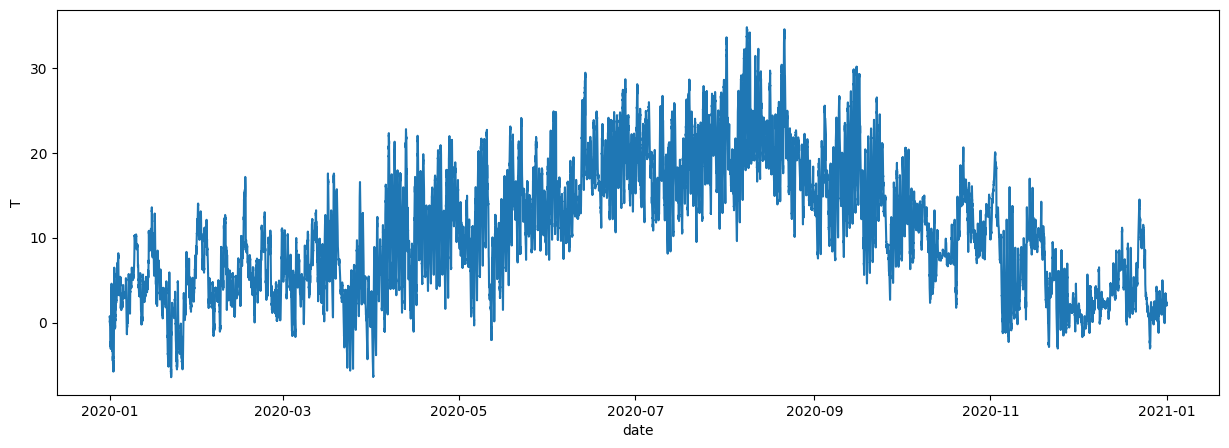

In [89]:
plt.figure(figsize=(15,5))
sns.lineplot(x=df.index,y='T',data=df)
plt.show()

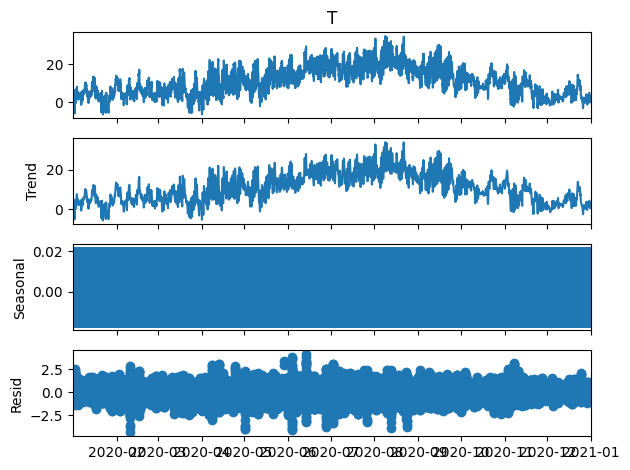

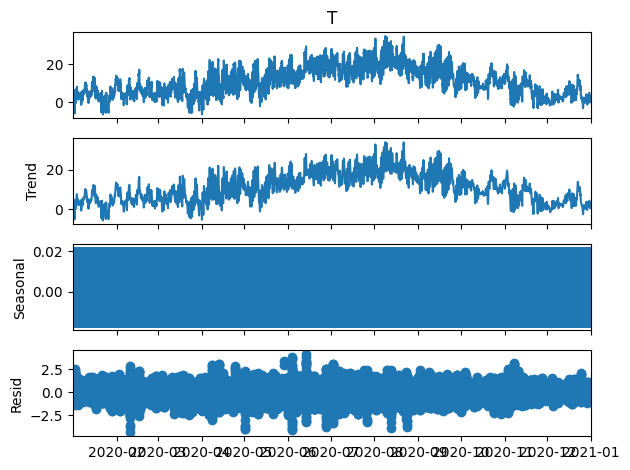

In [90]:
# decompostion and plots
decompose = seasonal_decompose(df['T'],model='additive',period=31)
decompose.plot()

In [94]:
# test for stationarity
def test_stationarity(timeseries):
  adf = adfuller(timeseries,autolag='AIC')
  print(f'ADF Statistic: {adf[0]}')
  print(f'p-value: {adf[1]}')
  result_adf = pd.Series(adf[0:4],index=['ADF Statistic','p-value','#Lags Used','Number of Observations Used'])
  for key,value in adf[4].items():
    result_adf['Critical Value (%s)'%key] = value
  print()

  kpss_test = kpss(timeseries,regression='ct')
  print(f'Kppss Statistic: {kpss_test[0]}')
  print(f'p-value: {kpss_test[1]}')

  result_kpss = pd.Series(kpss_test[0:3],index=['Test Statistic','p-value','Lags Used'])
  for key,value in kpss_test[3].items():
    result_kpss['Critical Value (%s)'%key] = value
  print(result_kpss)

  return result_adf,result_kpss

test_stationarity(df['T'])

ADF Statistic: -8.405910742505645
p-value: 2.1680033501417556e-13

Kppss Statistic: 6.980360893553991
p-value: 0.01
Test Statistic             6.980361
p-value                    0.010000
Lags Used                137.000000
Critical Value (10%)       0.119000
Critical Value (5%)        0.146000
Critical Value (2.5%)      0.176000
Critical Value (1%)        0.216000
dtype: float64


/tmp/ipykernel_1082/3246598603.py:11: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




(ADF Statistic                 -8.405911e+00
 p-value                        2.168003e-13
 #Lags Used                     5.800000e+01
 Number of Observations Used    5.263600e+04
 Critical Value (1%)           -3.430474e+00
 Critical Value (5%)           -2.861595e+00
 Critical Value (10%)          -2.566799e+00
 dtype: float64,
 Test Statistic             6.980361
 p-value                    0.010000
 Lags Used                137.000000
 Critical Value (10%)       0.119000
 Critical Value (5%)        0.146000
 Critical Value (2.5%)      0.176000
 Critical Value (1%)        0.216000
 dtype: float64)

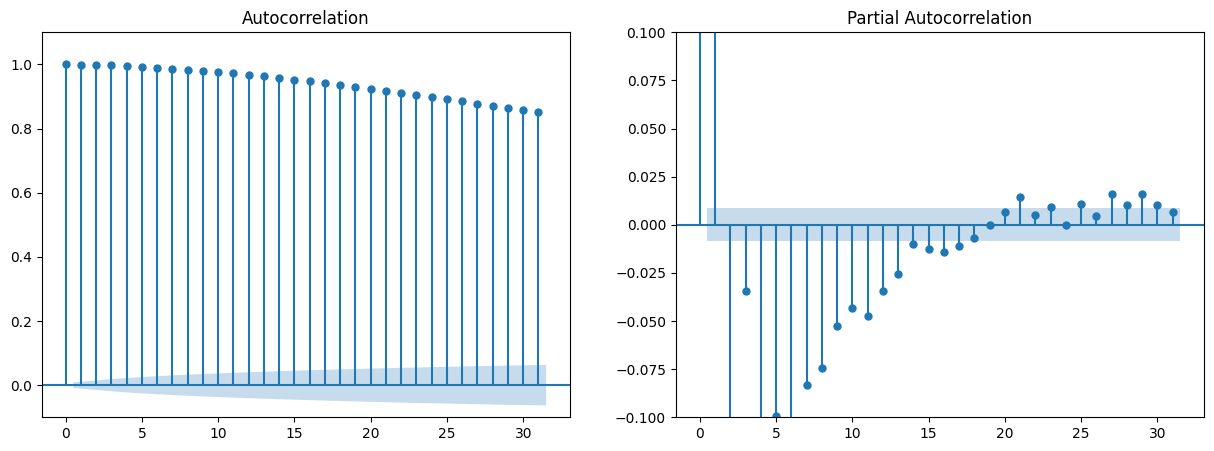

In [92]:
# plotting the acf and pcaf plots
def plot_acf_pacf(timeseries):
  fig,axes = plt.subplots(1,2,figsize=(15,5))
  plot_acf(timeseries,lags=31,ax=axes[0])
  plot_pacf(timeseries,lags=31,ax=axes[1])
  # Adjust y-axis limits for PACF plot to make confidence interval more visible
  axes[1].set_ylim([-0.1, 0.1])
  axes[0].set_ylim([-0.1, 1.1])
plot_acf_pacf(df['T'])

In [97]:
# making time series stationarity
## first apply differencing
df['first_diff'] = df['T'].diff(periods=30)
diff_df = df.copy()
diff_df.dropna(inplace=True)

test_stationarity(diff_df['T'])

ADF Statistic: -8.354691349565764
p-value: 2.9306180476956743e-13

Kppss Statistic: 6.977613353785057
p-value: 0.01
Test Statistic             6.977613
p-value                    0.010000
Lags Used                137.000000
Critical Value (10%)       0.119000
Critical Value (5%)        0.146000
Critical Value (2.5%)      0.176000
Critical Value (1%)        0.216000
dtype: float64


/tmp/ipykernel_1082/3246598603.py:11: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




(ADF Statistic                 -8.354691e+00
 p-value                        2.930618e-13
 #Lags Used                     5.800000e+01
 Number of Observations Used    5.260600e+04
 Critical Value (1%)           -3.430474e+00
 Critical Value (5%)           -2.861595e+00
 Critical Value (10%)          -2.566799e+00
 dtype: float64,
 Test Statistic             6.977613
 p-value                    0.010000
 Lags Used                137.000000
 Critical Value (10%)       0.119000
 Critical Value (5%)        0.146000
 Critical Value (2.5%)      0.176000
 Critical Value (1%)        0.216000
 dtype: float64)

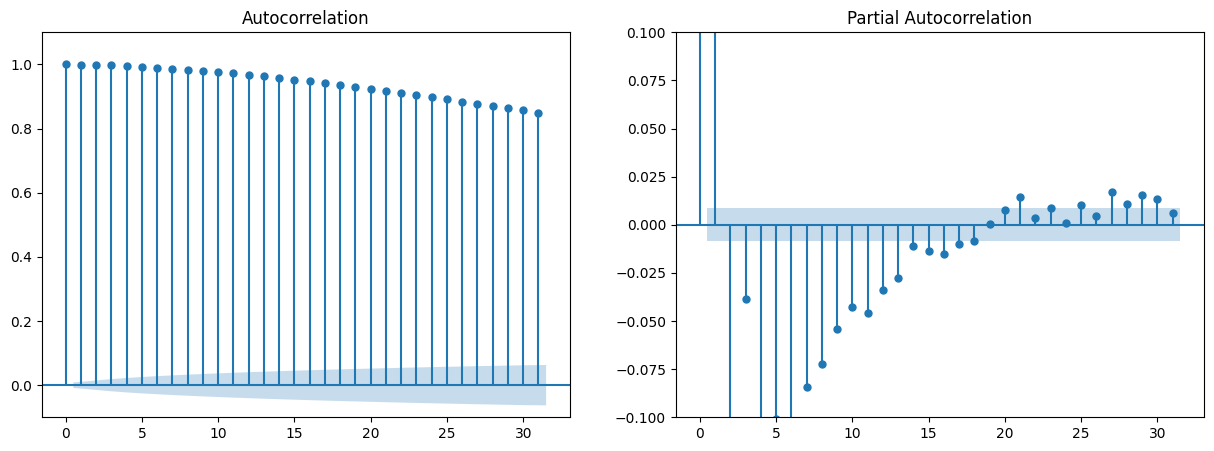

In [98]:
plot_acf_pacf(diff_df['T'])

In [100]:
# second_order diff
df['second_diff'] = df['T'].diff(periods=30).diff(periods=30)
diff_df = df.copy()
diff_df.dropna(inplace=True)

test_stationarity(diff_df['T'])

ADF Statistic: -8.414164586338575
p-value: 2.0651860293762747e-13

Kppss Statistic: 6.973013042718584
p-value: 0.01
Test Statistic             6.973013
p-value                    0.010000
Lags Used                137.000000
Critical Value (10%)       0.119000
Critical Value (5%)        0.146000
Critical Value (2.5%)      0.176000
Critical Value (1%)        0.216000
dtype: float64


/tmp/ipykernel_1082/3246598603.py:11: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




(ADF Statistic                 -8.414165e+00
 p-value                        2.065186e-13
 #Lags Used                     5.800000e+01
 Number of Observations Used    5.257600e+04
 Critical Value (1%)           -3.430474e+00
 Critical Value (5%)           -2.861595e+00
 Critical Value (10%)          -2.566799e+00
 dtype: float64,
 Test Statistic             6.973013
 p-value                    0.010000
 Lags Used                137.000000
 Critical Value (10%)       0.119000
 Critical Value (5%)        0.146000
 Critical Value (2.5%)      0.176000
 Critical Value (1%)        0.216000
 dtype: float64)

In [ ]:
# differencing is creating zero effect

In [102]:
## log transformations
df['log_T'] = np.log(df['T'])
log_df = df.copy()
log_df.dropna(inplace=True)

test_stationarity(log_df['T'])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in log



ADF Statistic: -8.680348807249006
p-value: 4.302917512139509e-14

Kppss Statistic: 6.910960237821378
p-value: 0.01
Test Statistic             6.91096
p-value                    0.01000
Lags Used                135.00000
Critical Value (10%)       0.11900
Critical Value (5%)        0.14600
Critical Value (2.5%)      0.17600
Critical Value (1%)        0.21600
dtype: float64


/tmp/ipykernel_1082/3246598603.py:11: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




(ADF Statistic                 -8.680349e+00
 p-value                        4.302918e-14
 #Lags Used                     5.700000e+01
 Number of Observations Used    5.035100e+04
 Critical Value (1%)           -3.430480e+00
 Critical Value (5%)           -2.861597e+00
 Critical Value (10%)          -2.566801e+00
 dtype: float64,
 Test Statistic             6.91096
 p-value                    0.01000
 Lags Used                135.00000
 Critical Value (10%)       0.11900
 Critical Value (5%)        0.14600
 Critical Value (2.5%)      0.17600
 Critical Value (1%)        0.21600
 dtype: float64)

In [103]:
# all differncing log transformation is use less by the way lstms is perfect it can handel non stationarity
# thus we are not going to use the arima , sarima , sarimax or so models
# we will compare the lstms with xgboost

In [104]:
# lets build lstm model

from sklearn.preprocessing import MinMaxScaler

# Extract the 'T' column for forecasting
data = df['T'].values.reshape(-1, 1)

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Function to create sequences for LSTM
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:(i + sequence_length), 0])
        y.append(data[i + sequence_length, 0])
    return np.array(X), np.array(y)

sequence_length = 30 # Using 30 as a look-back window, similar to previous differencing attempts
X, y = create_sequences(scaled_data, sequence_length)

# Split data into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape input to be 3D [samples, timesteps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [106]:
# Build the LSTM model
model = Sequential()
model.add(layers.LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(layers.Dropout(0.2))
model.add(layers.LSTM(units=50, return_sequences=False))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [109]:
# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test), verbose=1)

Epoch 1/5
659/659 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - loss: 0.0011 - val_loss: 1.2069e-04
Epoch 2/5
659/659 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - loss: 8.8624e-04 - val_loss: 2.1572e-04
Epoch 3/5
659/659 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - loss: 6.6529e-04 - val_loss: 9.1911e-05
Epoch 4/5
659/659 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - loss: 4.9859e-04 - val_loss: 8.6501e-05
Epoch 5/5
659/659 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - loss: 4.1311e-04 - val_loss: 9.9724e-05


In [110]:
# Make predictions on the test set
predictions = model.predict(X_test)

# Inverse transform the predictions and actual values to original scale
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate RMSE
rmse = np.sqrt(np.mean(((predictions - y_test_actual)**2)))
print(f'Root Mean Squared Error (RMSE): {rmse}')

330/330 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Root Mean Squared Error (RMSE): 0.4118309173745535


Now, let's visualize the actual temperatures against the predicted temperatures to get a better understanding of the model's performance.

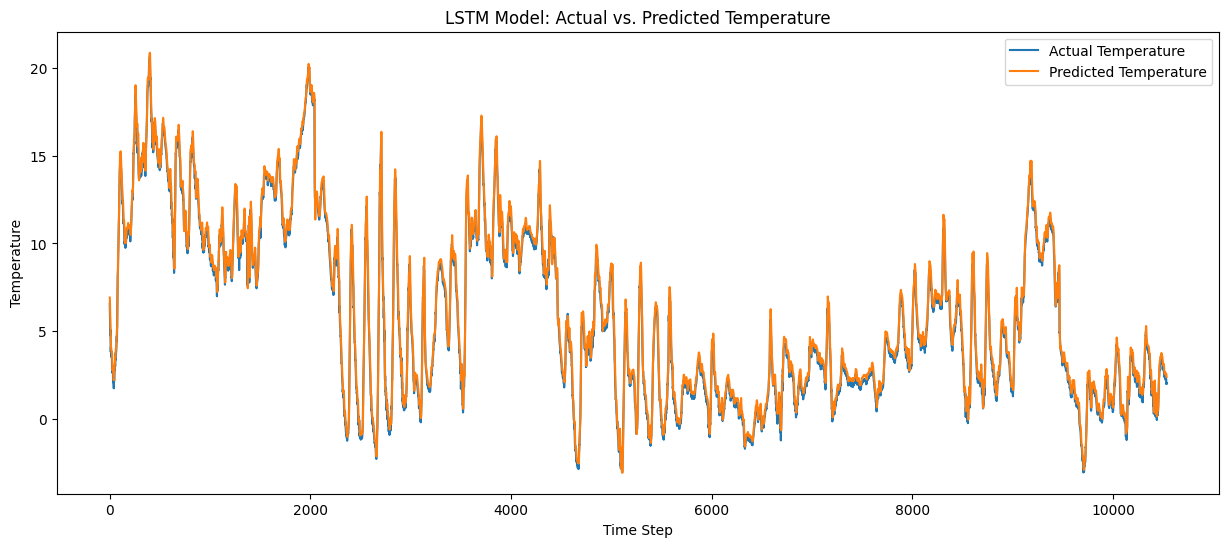

In [111]:
# Plot the results
plt.figure(figsize=(15, 6))
plt.plot(y_test_actual, label='Actual Temperature')
plt.plot(predictions, label='Predicted Temperature')
plt.title('LSTM Model: Actual vs. Predicted Temperature')
plt.xlabel('Time Step')
plt.ylabel('Temperature')
plt.legend()
plt.show()

### Multi-Feature LSTM Model: Data Loading and Preprocessing

In [112]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras import layers, Sequential
import matplotlib.pyplot as plt

# Reload the dataset with all features
df_multi = pd.read_csv('/content/cleaned_weather.csv')

# Initial cleaning steps
df_multi = df_multi.drop_duplicates()
df_multi['date'] = pd.to_datetime(df_multi['date'])
df_multi.set_index('date', inplace=True)
df_multi.sort_values(by='date', inplace=True)

# Display the head of the new dataframe
print("DataFrame with all features after initial cleaning:")
display(df_multi.head())

DataFrame with all features after initial cleaning:


,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,H2OC,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
date,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,5.49,1280.62,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45
2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,5.45,1280.33,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51
2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,5.43,1280.29,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60
2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,5.37,1281.97,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70
2020-01-01 00:50:00,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,5.42,1282.08,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81


### Feature Selection and Scaling for Multi-Feature LSTM

Now, we need to select all relevant features (excluding 'date' since it's the index) and the target variable ('T'). We will then scale all these features using `MinMaxScaler`.

In [113]:
# Select all columns as features, 'T' is the target
features = df_multi.columns.tolist()

df_multi_cleaned = df_multi.dropna()

# Features are all columns except 'T' which is the target for prediction
feature_cols = [col for col in df_multi_cleaned.columns if col != 'T']
data_multi = df_multi_cleaned[feature_cols + ['T']].values

# Scale the data
scaler_multi = MinMaxScaler(feature_range=(0, 1))
scaled_data_multi = scaler_multi.fit_transform(data_multi)

# Define target and features after scaling
# The last column is 'T', so features are all columns except the last one
X_multi = scaled_data_multi[:, :-1]
y_multi = scaled_data_multi[:, -1]

# Function to create sequences for LSTM (adjusted for multiple features)
def create_sequences_multi(data, target, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:(i + sequence_length), :]) # Take all features for the sequence
        y.append(target[i + sequence_length]) # Predict the target at the next step
    return np.array(X), np.array(y)

sequence_length_multi = 30 # Use the same sequence length as before
X_seq_multi, y_seq_multi = create_sequences_multi(X_multi, y_multi, sequence_length_multi)

# Split data into training and testing sets
train_size_multi = int(len(X_seq_multi) * 0.8)
X_train_multi, X_test_multi = X_seq_multi[:train_size_multi], X_seq_multi[train_size_multi:]
y_train_multi, y_test_multi = y_seq_multi[:train_size_multi], y_seq_multi[train_size_multi:]

# Reshape input to be 3D [samples, timesteps, features] for LSTM
# X_seq_multi is already in 3D (samples, timesteps, features) from create_sequences_multi
# So, no extra reshape needed if create_sequences_multi is implemented correctly.

print(f"Shape of X_train_multi: {X_train_multi.shape}")
print(f"Shape of y_train_multi: {y_train_multi.shape}")
print(f"Shape of X_test_multi: {X_test_multi.shape}")
print(f"Shape of y_test_multi: {y_test_multi.shape}")

Shape of X_train_multi: (42132, 30, 19)
Shape of y_train_multi: (42132,)
Shape of X_test_multi: (10533, 30, 19)
Shape of y_test_multi: (10533,)


### Multi-Feature LSTM Model Definition and Training

Now, we define and train the LSTM model. The main difference from the previous model will be the `input_shape` of the first LSTM layer, which now needs to accommodate multiple features.

In [114]:
# Build the LSTM model with multiple features
model_multi = Sequential()
model_multi.add(layers.LSTM(units=50, return_sequences=True, input_shape=(X_train_multi.shape[1], X_train_multi.shape[2])))
model_multi.add(layers.Dropout(0.2))
model_multi.add(layers.LSTM(units=50, return_sequences=False))
model_multi.add(layers.Dropout(0.2))
model_multi.add(layers.Dense(units=1))

# Compile the model
model_multi.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
print("Multi-feature LSTM Model Summary:")
model_multi.summary()

# Train the model
print("\nTraining Multi-feature LSTM Model...")
history_multi = model_multi.fit(X_train_multi, y_train_multi, epochs=5, batch_size=64, validation_data=(X_test_multi, y_test_multi), verbose=1)

Multi-feature LSTM Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 50)         │        14,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,251 (133.79 KB)

 Trainable params: 34,251 (133.79 KB)

 Non-trainable params: 0 (0.00 B)


Training Multi-feature LSTM Model...
Epoch 1/5
659/659 ━━━━━━━━━━━━━━━━━━━━ 31s 43ms/step - loss: 0.0040 - val_loss: 5.1955e-04
Epoch 2/5
659/659 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - loss: 0.0014 - val_loss: 1.2072e-04
Epoch 3/5
659/659 ━━━━━━━━━━━━━━━━━━━━ 43s 45ms/step - loss: 9.9807e-04 - val_loss: 9.2043e-05
Epoch 4/5
659/659 ━━━━━━━━━━━━━━━━━━━━ 32s 49ms/step - loss: 7.2330e-04 - val_loss: 7.5271e-05
Epoch 5/5
659/659 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - loss: 5.3054e-04 - val_loss: 9.5679e-05


### Multi-Feature LSTM Model Prediction and Evaluation

Finally, we make predictions using the trained multi-feature LSTM model, inverse transform the results to the original scale, calculate the RMSE, and visualize the actual versus predicted temperatures.

330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Root Mean Squared Error (RMSE) for Multi-feature LSTM: 0.40339177446171703


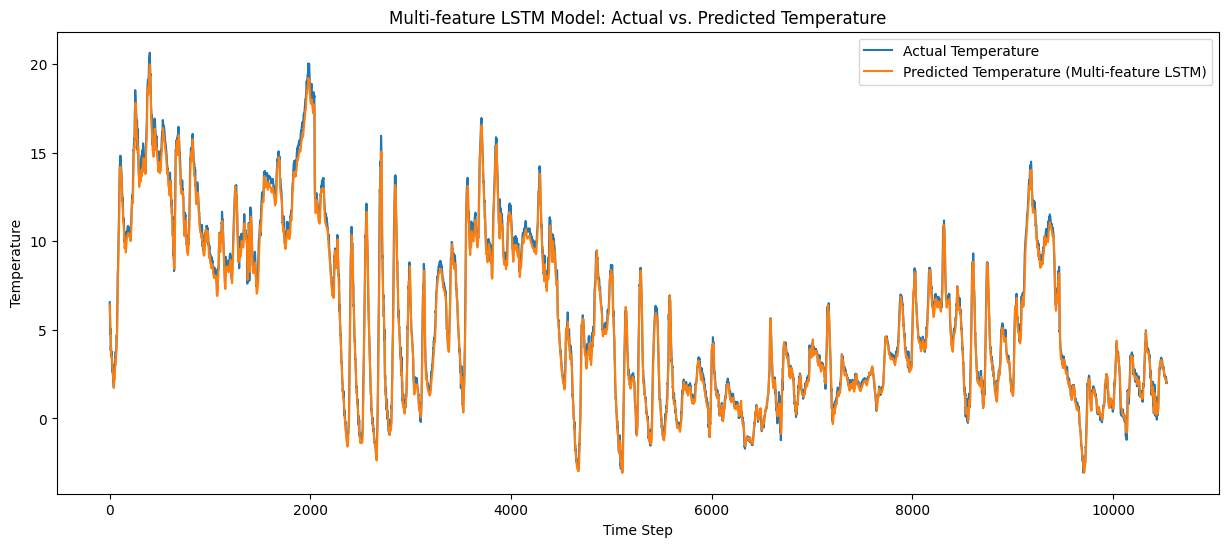

In [115]:
# Make predictions on the test set
predictions_multi = model_multi.predict(X_test_multi)

dummy_predictions = np.zeros((len(predictions_multi), len(feature_cols) + 1))
dummy_predictions[:, -1] = predictions_multi.flatten()
predictions_multi_actual_scale = scaler_multi.inverse_transform(dummy_predictions)[:, -1]

dummy_y_test = np.zeros((len(y_test_multi), len(feature_cols) + 1))
dummy_y_test[:, -1] = y_test_multi.flatten()
y_test_multi_actual_scale = scaler_multi.inverse_transform(dummy_y_test)[:, -1]

# Calculate RMSE
rmse_multi = np.sqrt(np.mean(((predictions_multi_actual_scale - y_test_multi_actual_scale)**2)))
print(f'Root Mean Squared Error (RMSE) for Multi-feature LSTM: {rmse_multi}')

# Plot the results
plt.figure(figsize=(15, 6))
plt.plot(y_test_multi_actual_scale, label='Actual Temperature')
plt.plot(predictions_multi_actual_scale, label='Predicted Temperature (Multi-feature LSTM)')
plt.title('Multi-feature LSTM Model: Actual vs. Predicted Temperature')
plt.xlabel('Time Step')
plt.ylabel('Temperature')
plt.legend()
plt.show()